In [12]:
# Importing
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

About this file
1. longitude: A measure of how far west a house is; a higher value is farther west

2. latitude: A measure of how far north a house is; a higher value is farther north

3. housingMedianAge: Median age of a house within a block; a lower number is a newer building

4. totalRooms: Total number of rooms within a block

5. totalBedrooms: Total number of bedrooms within a block

6. population: Total number of people residing within a block

7. households: Total number of households, a group of people residing within a home unit, for a block

8. medianIncome: Median income for households within a block of houses (measured in tens of thousands of US Dollars)

9. medianHouseValue: Median house value for households within a block (measured in US Dollars)

# Basic EDA

In [13]:
# Load Dataset
df = pd.read_csv('./data/calihousing.csv')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [15]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [16]:
df.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

## Noww i will try to make this data ready for modelling by removing the missing values and making sure all columns are in numerical format

In [17]:
# Dealing with missing values :(
df['total_bedrooms'] = pd.to_numeric(df['total_bedrooms'], errors='coerce')
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())
df.isna().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

### Sorting the columns now

In [18]:
df['rooms_per_household'] = df['total_rooms'] / df['households']
df['bedrooms_per_rooms'] = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population'] / df['households']

In [19]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,rooms_per_household,bedrooms_per_rooms,population_per_household
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,6.984127,0.146591,2.555556
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,6.238137,0.155797,2.109842
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,8.288136,0.129516,2.802260
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,5.817352,0.184458,2.547945
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,6.281853,0.172096,2.181467


### Now the data is somewhat sorted :) i'll check the correlation 

Text(0.5, 1.0, 'Correlation Heatmap')

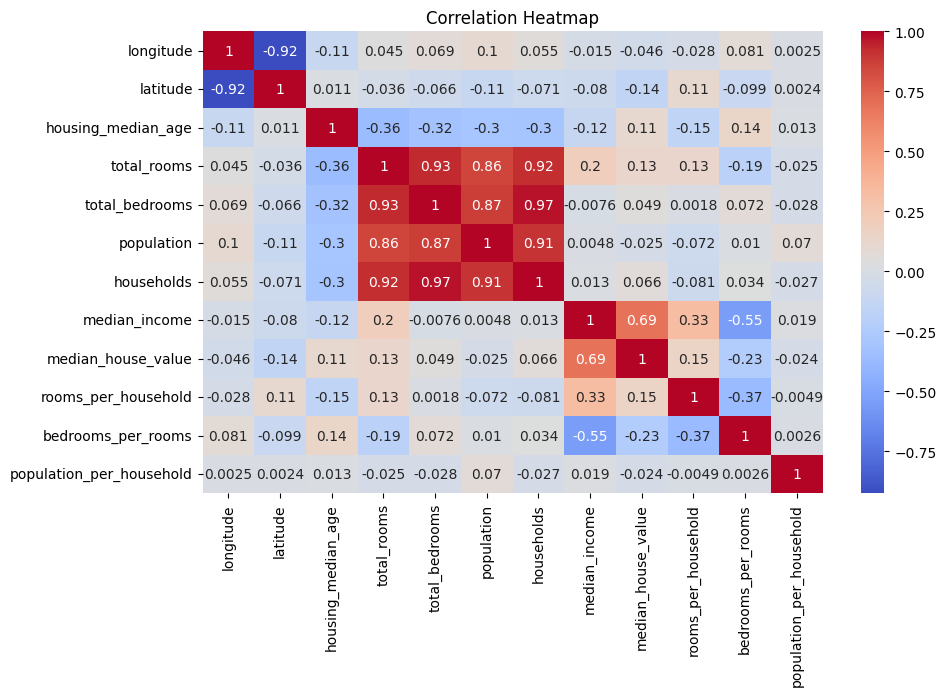

In [20]:
plt.figure(figsize = (10,6))
sns.heatmap((df.drop(['ocean_proximity'],axis =1)).corr(),annot=True,cmap = 'coolwarm')
plt.title('Correlation Heatmap')

### Visualizing Target Variable

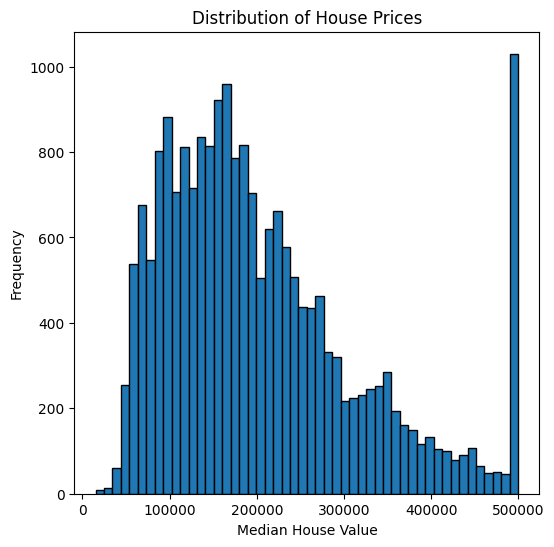

In [21]:
plt.figure(figsize = (6,6))
plt.hist(df['median_house_value'],bins=50,edgecolor='black');
plt.title('Distribution of House Prices')
plt.xlabel('Median House Value')
plt.ylabel('Frequency');

### Nowww i will check skewness in the data by plotting a histogram on all the data

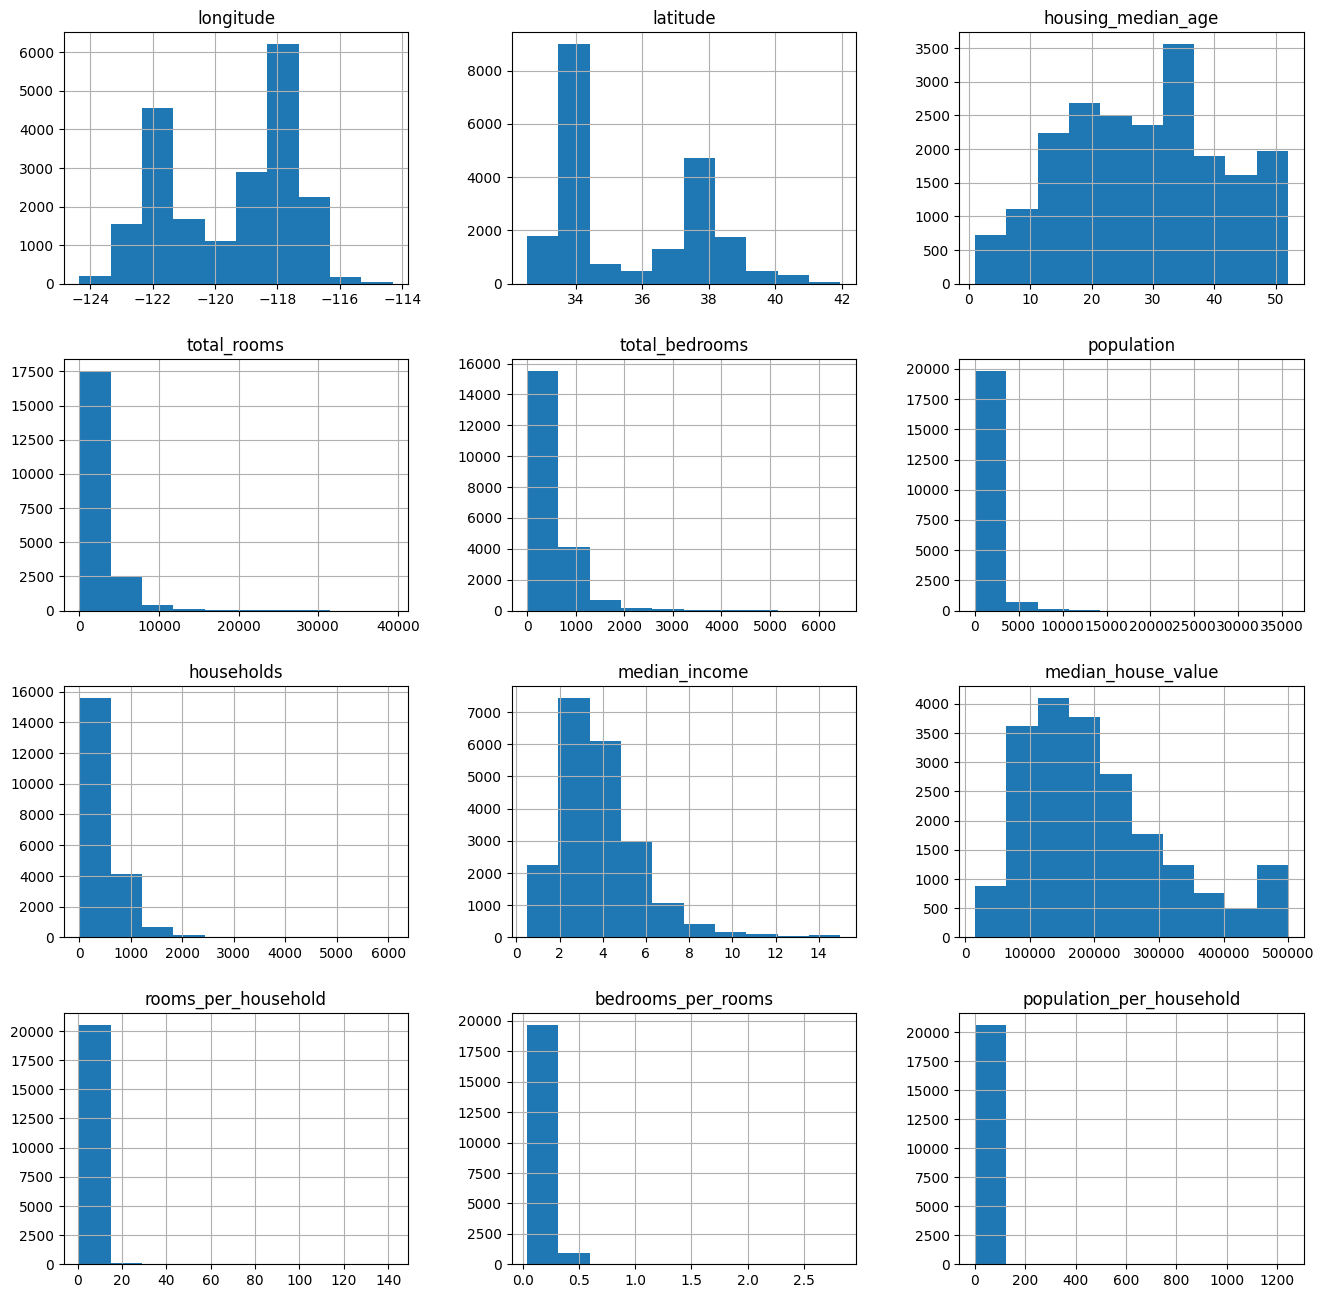

In [22]:
df.hist(figsize=(16,16));

Lets check our categorical column

In [25]:
## Handling the categorical data
df['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

### One hot encoding the data 

In [26]:
df = pd.get_dummies(df,drop_first = True)
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,bedrooms_per_rooms,population_per_household,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,6.781058,4.867534,5.777652,4.844187,8.3252,452600.0,2.077455,0.136793,1.268511,False,False,True,False
1,-122.22,37.86,21.0,8.867850,7.009409,7.784057,7.037906,8.3014,358500.0,1.979364,0.144790,1.134572,False,False,True,False
2,-122.24,37.85,52.0,7.291656,5.252273,6.208590,5.181784,7.2574,352100.0,2.228738,0.121789,1.335596,False,False,True,False
3,-122.25,37.85,52.0,7.150701,5.463832,6.326149,5.393628,5.6431,341300.0,1.919471,0.169286,1.266369,False,False,True,False
4,-122.25,37.85,52.0,7.395108,5.638355,6.338594,5.560682,3.8462,342200.0,1.985385,0.158793,1.157342,False,False,True,False


### Checking correlation between the area of the property 

<Axes: xlabel='latitude', ylabel='longitude'>

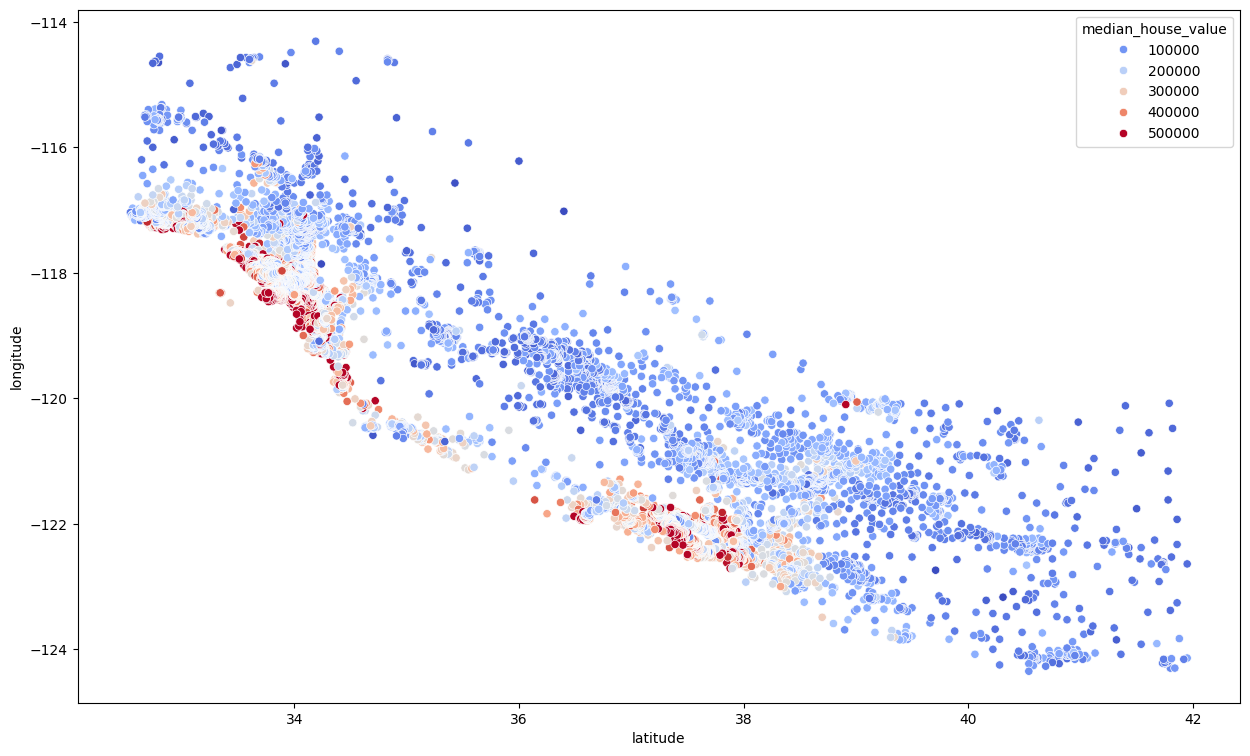

In [28]:
plt.figure(figsize=(15,9))
sns.scatterplot(x='latitude', y='longitude',data=df,hue = 'median_house_value',palette = 'coolwarm')

### While looking at this and the california map, we can see that the properties closer to the coast have a higher median house value

# Preparing data for modelling

### To have an unbiased and to ensure that all features contribute equally we use standard scaler

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

x = df.drop('median_house_value', axis=1)
y = df['median_house_value']

In [20]:
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size = 0.2, random_state = 42)

In [21]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# Building the model

In [22]:
from sklearn.ensemble import RandomForestRegressor


In [23]:
model = RandomForestRegressor()

model.fit(x_train_scaled,y_train)

RandomForestRegressor()

In [24]:
model.score(x_test_scaled,y_test)

0.8048769680549965

### Making Predictions

In [25]:
y_train_preds = model.predict(x_train_scaled)
y_test_preds = model.predict(x_test_scaled)

### Calclualting metrics


In [26]:
from sklearn.metrics import mean_squared_error,r2_score

In [27]:
train_rmse = np.sqrt(mean_squared_error(y_train,y_train_preds))
test_rmse = np.sqrt(mean_squared_error(y_test,y_test_preds))
train_r2 = r2_score(y_train,y_train_preds)
test_r2 = r2_score(y_test,y_test_preds)

print("\nRandom Forest Metrics")
print(f"Train RMSE: {train_rmse:2f}")
print(f"Test RMSE: {test_rmse:2f}")
print(f"Train R2: {train_r2:2f}")
print(f"Test R2: {test_r2:2f}")


Random Forest Metrics
Train RMSE: 18504.779588
Test RMSE: 50565.894922
Train R2: 0.974384
Test R2: 0.804877


### Now we will visualize the most important features in our dataset

Text(0.5, 0, 'Importance')

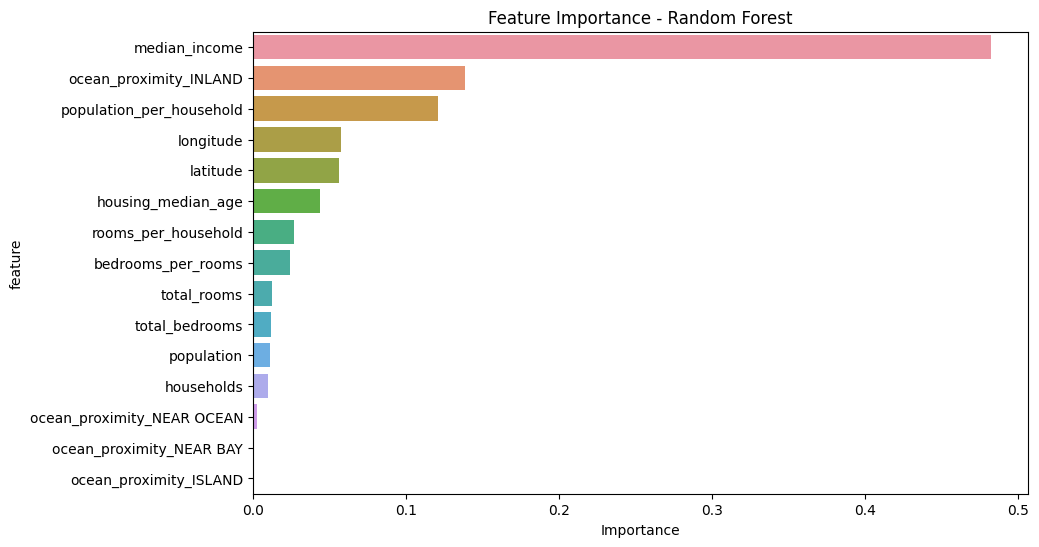

In [28]:
# Feature Importance
feature_importance = pd.DataFrame({
    'feature': x.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance')

### Now i will apply grid search cv to get the accuracy score of the best parameters in the model

In [29]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

In [30]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}


In [31]:
# Grid search
model = RandomForestRegressor()
grid_search = GridSearchCV(
    model,
    param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

In [32]:
grid_search.fit(x_train_scaled, y_train)


GridSearchCV(cv=3, estimator=RandomForestRegressor(), n_jobs=-1,
             param_grid={'max_depth': [10, 20, None],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='neg_mean_squared_error')

In [33]:
best_rf = grid_search.best_estimator_
best_rf.score(x_test_scaled, y_test)

0.8091715834877323